In [2]:
import io
import sys
from contextlib import redirect_stdout
import os
import geopandas as gpd
import pandas as pd
import numpy as np
from datetime import datetime
from dateutil.relativedelta import relativedelta
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
import pingouin as pg
import requests
from shapely.geometry import Polygon
from shapely.geometry import Point
import matplotlib.pyplot as plt


# Alistamiento de datos para correlaciones

Se corre cuando se tiene una nueva base de datos para alistar el archivo, sólo se debe hacer una vez, y dicho archivo queda guardado, mostrandose en el siguiente bloque

In [ ]:
dfg=gpd.read_file(r'/content/drive/Shareddrives/PIGCC/Satelite/Scripts/Cobertura_de_la_tierra_100K_Periodo_2020_limite_administrativo/shape Limite admin/e_cobertura_tierra_2020_admin.shp')#8\COBERTURAS CORINE 2018\shape coberturas 2018\cobertura_tierra_clc_2018.shp')
dfg.plot('nivel_1',legend=True)

In [ ]:
dfg.columns

In [ ]:
mydict1={'1':'1. Territorios artificializados','2':'2. Territorios agrícolas','3':'3. Bosques y áreas seminaturales','4':'4. Áreas húmedas','5':'5. Superficies de agua'}
mydict1

In [ ]:
import csv

with open('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/Nivel3.csv', mode='r') as infile:
    reader = csv.reader(infile)
    with open('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/N3.csv', mode='w') as outfile:
        writer = csv.writer(outfile)
        mydict = {rows[1]:rows[0] for rows in reader}
mydict

In [ ]:
dfg['Leyenda_1']=dfg['nivel_1'].map(mydict1)
dfg[['Leyenda_1','nivel_1']]

In [ ]:
dfg['Leyenda_3']=dfg['nivel_3'].map(mydict)
dfg[['Leyenda_3','nivel_3']]

In [ ]:
encoded_df = pd.get_dummies(dfg, columns=["Leyenda_3"])  # Encode the "leyenda 3" column
encoded_df1 = pd.get_dummies(dfg, columns=["Leyenda_1"])  # Encode the "Leyenda 1" column
#print(encoded_df1.columns)
encoded_df=pd.concat([encoded_df,encoded_df1[['Leyenda_1_1. Territorios artificializados', 'Leyenda_1_2. Territorios agrícolas', 'Leyenda_1_3. Bosques y áreas seminaturales','Leyenda_1_4. Áreas húmedas',
       'Leyenda_1_5. Superficies de agua']]], axis=1)
encoded_df['groupb']=0
encoded_df

In [ ]:
df_s=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/colombia_prom_2020_filtered.csv')
sns.scatterplot(data=df_s,x='longitude',y='latitude',s=0.5)#,hue='CH4_column_volume_mixing_ratio_dry_air_bias_corrected')

In [ ]:
#df_s.groupby(['latitude','longitude']).mean('CH4_column_volume_mixing_ratio_dry_air_bias_corrected').to_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/datos corregidos/colombia_prom.csv')

In [ ]:
df_s

In [ ]:
df_s['coordinate_x']=df_s['longitude'].apply(lambda x: [x])
df_s['coordinate_y']=df_s['latitude'].apply(lambda x: [x])
df_s['coordinates']=df_s['coordinate_x']+df_s['coordinate_y']
df_s

In [ ]:
delta_y=0.01
delta_x=0.01
df_s['geometry'] = df_s['coordinates'].apply(
    lambda x: Polygon([
        (x[0] - delta_x, x[1] - delta_y),
        (x[0] - delta_x, x[1] + delta_y),
        (x[0] + delta_x, x[1] + delta_y),
        (x[0] + delta_x, x[1] - delta_y)
    ]))# Corregir el delta

In [ ]:
l_in=list(encoded_df.columns)
while not l_in[0]=='Leyenda_3_1.1.1. Tejido urbano continuo':
    l_in.pop(0)#(list(dfg.columns))
l_in.remove('groupb')
for i in l_in:
    encoded_df[i]=encoded_df[i]*encoded_df['SHAPE_Area']
df_s.loc[:,l_in]=None
df_s['Leyenda_1_4. Áreas húmedas'][0]

In [ ]:
for j in df_s.index:
    #print(j)
    f=encoded_df[df_s['geometry'][j].intersects(encoded_df['geometry'])]
    f1=f.groupby('groupb')[l_in].aggregate('sum') # Se suma el área total intersectada
    if not len(f1)==0:
        #print(j)
        for i in l_in:
            df_s.loc[j, i]=f1[i].iloc[0].copy()

In [ ]:
df_s

In [ ]:
#Eliminar zonas de agua para evitar glint

In [ ]:
df_s.to_csv('/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/corr_land_2020.csv')

#df_s=pd.read_csv(r'/content/drive/Shareddrives/PIGCC/Satelite/datos_csv/glint_intersect.csv')

# Análisis de correlaciones

In [3]:
df_corr=pd.read_csv(r'corr_land_2020new.csv',index_col=0)
df_corr[(~(df_corr['Leyenda_1_5. Superficies de agua']>0))*(~(df_corr['Leyenda_1_4. Áreas húmedas']>0))]#+

,longitude,latitude,time,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,coordinate_x,coordinate_y,coordinates,geometry,Leyenda_3_1.1.1. Tejido urbano continuo,Leyenda_3_1.1.2. Tejido urbano discontinuo,...,Leyenda_3_5.1.3. Canales,Leyenda_3_5.1.4. Cuerpos de agua artificiales,Leyenda_3_5.2.1. Lagunas costeras,Leyenda_3_5.2.2. Mares y océanos,Leyenda_3_5.2.3. Estanques para acuicultura marina,Leyenda_1_1. Territorios artificializados,Leyenda_1_2. Territorios agrícolas,Leyenda_1_3. Bosques y áreas seminaturales,Leyenda_1_4. Áreas húmedas,Leyenda_1_5. Superficies de agua
0,-77.305,7.745,1.606068e+12,1866.559650,[-77.305],[7.745],"[-77.305, 7.745]","POLYGON ((-77.31 7.74, -77.31 7.75, -77.300000...",0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000038,0.286843,0.0,0.0
1,-77.305,7.755,1.606068e+12,1866.559615,[-77.305],[7.755],"[-77.305, 7.755]","POLYGON ((-77.31 7.75, -77.31 7.76, -77.300000...",0.0,0.000006,...,0.0,0.0,0.0,0.0,0.0,0.000006,0.000161,0.286593,0.0,0.0
2,-77.295,7.705,1.606068e+12,1866.559567,[-77.295],[7.705],"[-77.295, 7.705]","POLYGON ((-77.3 7.7, -77.3 7.71, -77.29 7.71, ...",0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000725,0.000777,0.0,0.0
3,-77.295,7.715,1.606068e+12,1866.559602,[-77.295],[7.715],"[-77.295, 7.715]","POLYGON ((-77.3 7.71, -77.3 7.72, -77.29 7.72,...",0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000482,0.000854,0.0,0.0
4,-77.295,7.725,1.606068e+12,1866.559608,[-77.295],[7.725],"[-77.295, 7.725]","POLYGON ((-77.3 7.72, -77.3 7.7299999999999995...",0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000328,0.000878,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307148,-67.325,3.435,1.577987e+12,1835.456487,[-67.325],[3.435],"[-67.325, 3.435]","POLYGON ((-67.33 3.43, -67.33 3.44, -67.320000...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307149,-67.325,3.445,1.577987e+12,1835.456421,[-67.325],[3.4450000000000003],"[-67.325, 3.4450000000000003]","POLYGON ((-67.33 3.4400000000000004, -67.33 3....",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307150,-67.325,3.455,1.577987e+12,1835.456421,[-67.325],[3.455],"[-67.325, 3.455]","POLYGON ((-67.33 3.45, -67.33 3.46, -67.320000...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307153,-67.315,3.435,1.577987e+12,1835.456439,[-67.315],[3.435],"[-67.315, 3.435]","POLYGON ((-67.32 3.43, -67.32 3.44, -67.31 3.4...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,longitude,latitude,time,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,coordinate_x,coordinate_y,coordinates,geometry,Leyenda_3_1.1.1. Tejido urbano continuo,Leyenda_3_1.1.2. Tejido urbano discontinuo,...,Leyenda_3_5.1.3. Canales,Leyenda_3_5.1.4. Cuerpos de agua artificiales,Leyenda_3_5.2.1. Lagunas costeras,Leyenda_3_5.2.2. Mares y océanos,Leyenda_3_5.2.3. Estanques para acuicultura marina,Leyenda_1_1. Territorios artificializados,Leyenda_1_2. Territorios agrícolas,Leyenda_1_3. Bosques y áreas seminaturales,Leyenda_1_4. Áreas húmedas,Leyenda_1_5. Superficies de agua
0,-77.305,7.745,1.606068e+12,1866.559650,[-77.305],[7.745],"[-77.305, 7.745]","POLYGON ((-77.31 7.74, -77.31 7.75, -77.300000...",0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000038,0.286843,0.0,0.0
1,-77.305,7.755,1.606068e+12,1866.559615,[-77.305],[7.755],"[-77.305, 7.755]","POLYGON ((-77.31 7.75, -77.31 7.76, -77.300000...",0.0,0.000006,...,0.0,0.0,0.0,0.0,0.0,0.000006,0.000161,0.286593,0.0,0.0
2,-77.295,7.705,1.606068e+12,1866.559567,[-77.295],[7.705],"[-77.295, 7.705]","POLYGON ((-77.3 7.7, -77.3 7.71, -77.29 7.71, ...",0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000725,0.000777,0.0,0.0
3,-77.295,7.715,1.606068e+12,1866.559602,[-77.295],[7.715],"[-77.295, 7.715]","POLYGON ((-77.3 7.71, -77.3 7.72, -77.29 7.72,...",0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000482,0.000854,0.0,0.0
4,-77.295,7.725,1.606068e+12,1866.559608,[-77.295],[7.725],"[-77.295, 7.725]","POLYGON ((-77.3 7.72, -77.3 7.7299999999999995...",0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.000328,0.000878,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307148,-67.325,3.435,1.577987e+12,1835.456487,[-67.325],[3.435],"[-67.325, 3.435]","POLYGON ((-67.33 3.43, -67.33 3.44, -67.320000...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307149,-67.325,3.445,1.577987e+12,1835.456421,[-67.325],[3.4450000000000003],"[-67.325, 3.4450000000000003]","POLYGON ((-67.33 3.4400000000000004, -67.33 3....",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307150,-67.325,3.455,1.577987e+12,1835.456421,[-67.325],[3.455],"[-67.325, 3.455]","POLYGON ((-67.33 3.45, -67.33 3.46, -67.320000...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307153,-67.315,3.435,1.577987e+12,1835.456439,[-67.315],[3.435],"[-67.315, 3.435]","POLYGON ((-67.32 3.43, -67.32 3.44, -67.31 3.4...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


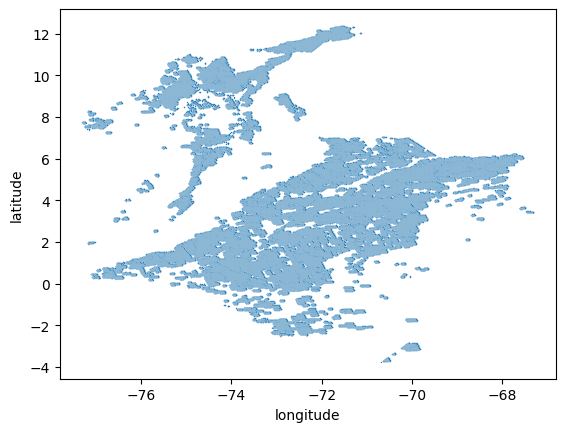

In [4]:
df_corr=df_corr[(~(df_corr['Leyenda_1_5. Superficies de agua']>0))*(~(df_corr['Leyenda_1_4. Áreas húmedas']>0))]
sns.scatterplot(data=df_corr,x='longitude',y='latitude',s=1)
df_corr

In [5]:
l_in=list(df_corr.columns)
#l_in.remove(['longitude', 'latitude','CH4_column_volume_mixing_ratio_dry_air_bias_corrected', 'coordinate_x','coordinate_y', 'coordinates', 'geometry'])
while not l_in[0]=='Leyenda_3_1.1.1. Tejido urbano continuo':
    l_in.pop(0)#(list(dfg.columns))
l_in

['Leyenda_3_1.1.1. Tejido urbano continuo',
 'Leyenda_3_1.1.2. Tejido urbano discontinuo',
 'Leyenda_3_1.2.1. Zonas industriales o comerciales',
 'Leyenda_3_1.2.2. Red vial, ferroviaria y terrenos asociados',
 'Leyenda_3_1.2.3. Zonas portuarias',
 'Leyenda_3_1.2.4. Aeropuertos',
 'Leyenda_3_1.2.5. Obras hidráulicas',
 'Leyenda_3_1.3.1. Zonas de extracción minera',
 'Leyenda_3_1.3.2. Zona de disposición de residuos',
 'Leyenda_3_1.4.1. Zonas verdes urbanas',
 'Leyenda_3_1.4.2. Instalaciones recreativas',
 'Leyenda_3_2.1.1. Otros cultivos transitorios',
 'Leyenda_3_2.1.2. Cereales',
 'Leyenda_3_2.1.3. Oleaginosas y leguminosas',
 'Leyenda_3_2.1.4. Hortalizas',
 'Leyenda_3_2.1.5. Tubérculos',
 'Leyenda_3_2.2.1. Cultivos permanentes herbáceos',
 'Leyenda_3_2.2.2. Cultivos permanentes arbustivos',
 'Leyenda_3_2.2.3. Cultivos permanentes arbóreos',
 'Leyenda_3_2.2.4. Cultivos agroforestales',
 'Leyenda_3_2.2.5. Cultivos confinados',
 'Leyenda_3_2.3.1. Pastos limpios',
 'Leyenda_3_2.3.2. Past

In [6]:
correlaciones=df_corr.corr(numeric_only=True)['CH4_column_volume_mixing_ratio_dry_air_bias_corrected']
correlaciones

longitude                                               -0.159037
latitude                                                 0.490301
time                                                     0.351134
CH4_column_volume_mixing_ratio_dry_air_bias_corrected    1.000000
Leyenda_3_1.1.1. Tejido urbano continuo                  0.021185
                                                           ...   
Leyenda_1_1. Territorios artificializados                0.028335
Leyenda_1_2. Territorios agrícolas                       0.122896
Leyenda_1_3. Bosques y áreas seminaturales              -0.487323
Leyenda_1_4. Áreas húmedas                                    NaN
Leyenda_1_5. Superficies de agua                              NaN
Name: CH4_column_volume_mixing_ratio_dry_air_bias_corrected, Length: 64, dtype: float64

In [7]:
print(len(correlaciones))
correlaciones.sort_values(ascending=False).head(10)


64


CH4_column_volume_mixing_ratio_dry_air_bias_corrected        1.000000
latitude                                                     0.490301
time                                                         0.351134
Leyenda_3_3.2.1. Herbazal                                    0.144867
Leyenda_3_2.3.3. Pastos enmalezados                          0.127166
Leyenda_1_2. Territorios agrícolas                           0.122896
Leyenda_3_2.3.1. Pastos limpios                              0.119258
Leyenda_3_2.4.4. Mosaico de pastos con espacios naturales    0.113466
Leyenda_3_3.1.4. Bosque de galería y ripario                 0.111960
Leyenda_3_2.3.2. Pastos arbolados                            0.081272
Name: CH4_column_volume_mixing_ratio_dry_air_bias_corrected, dtype: float64

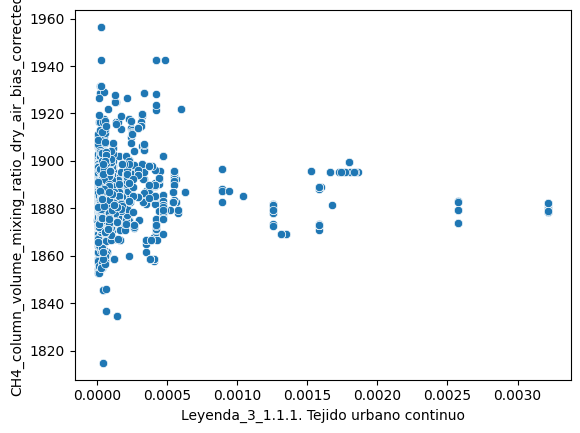

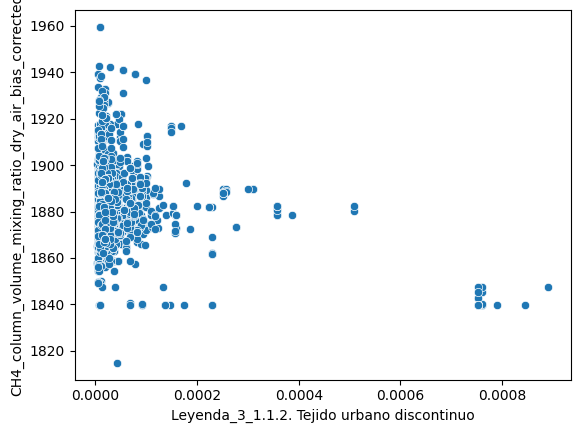

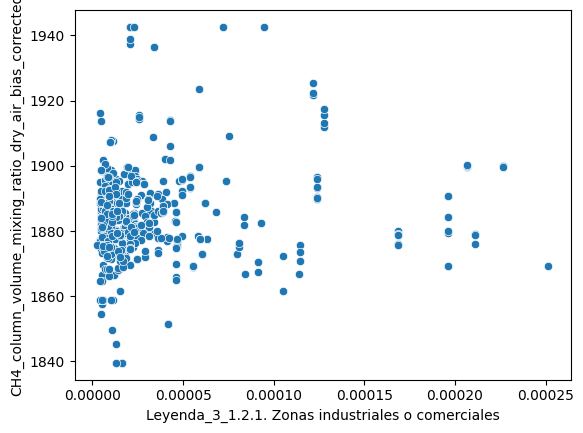

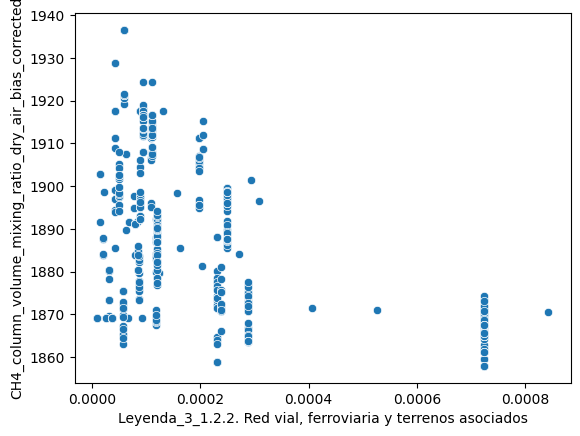

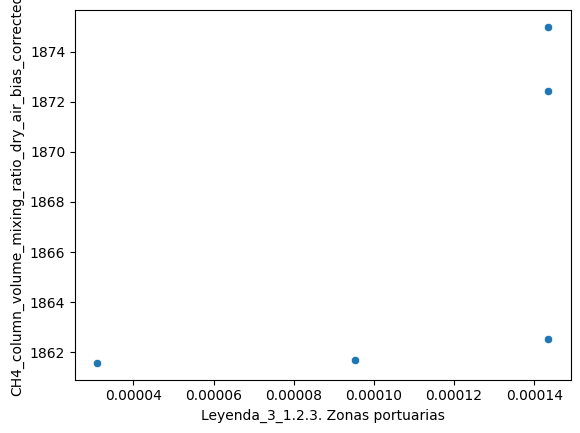

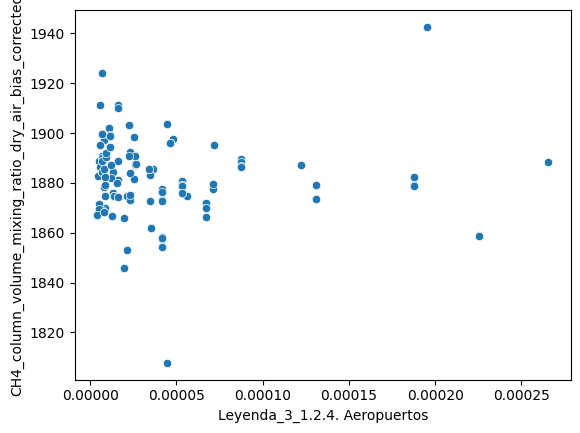

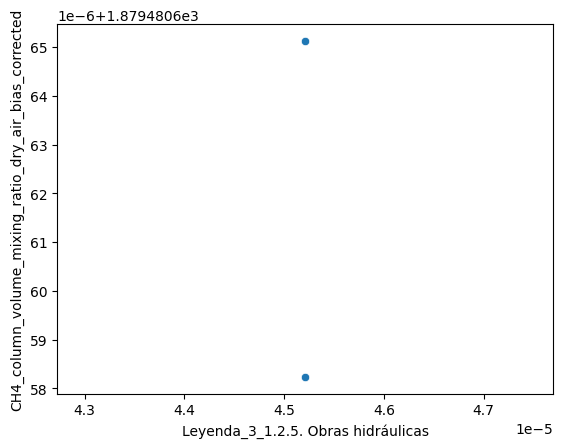

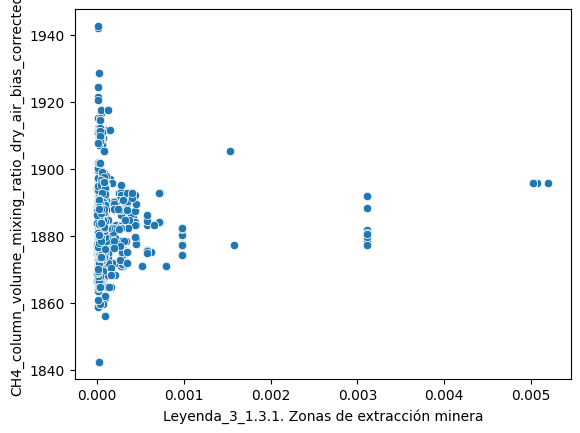

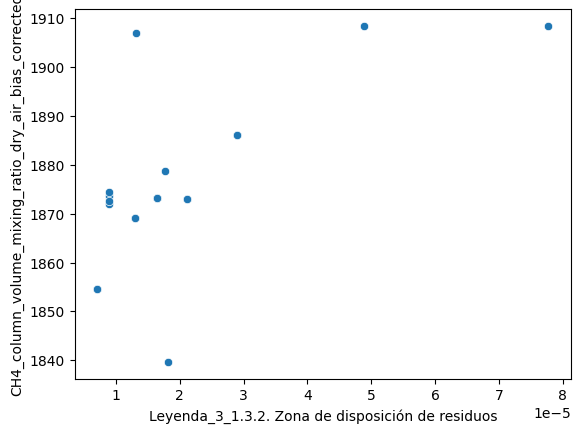

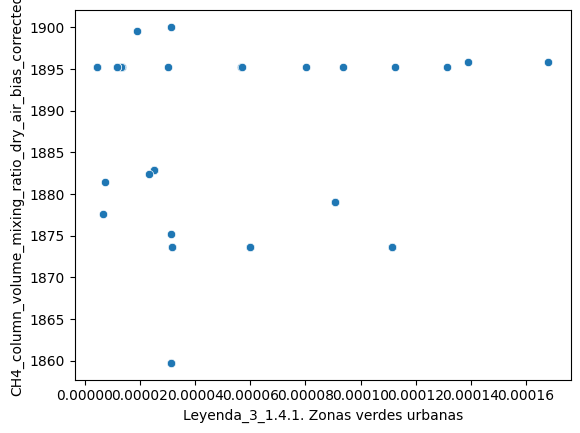

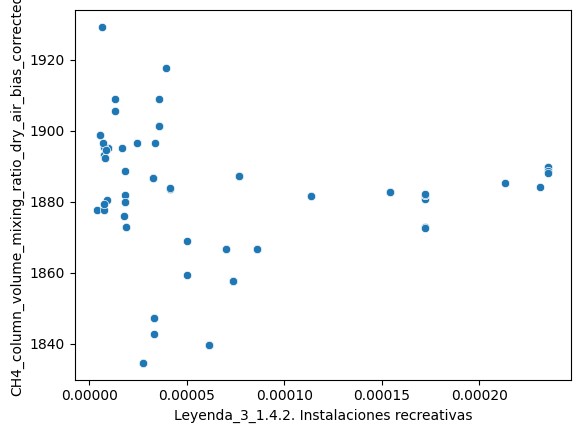

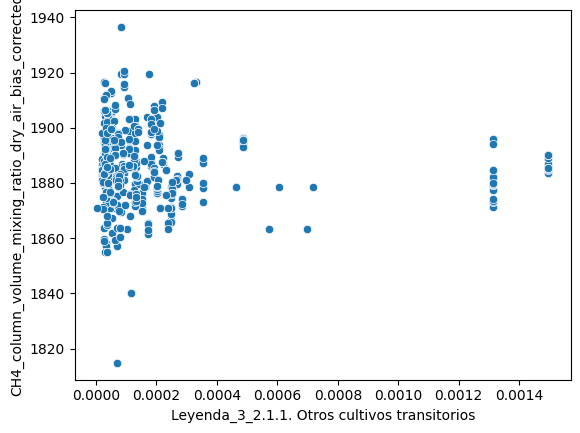

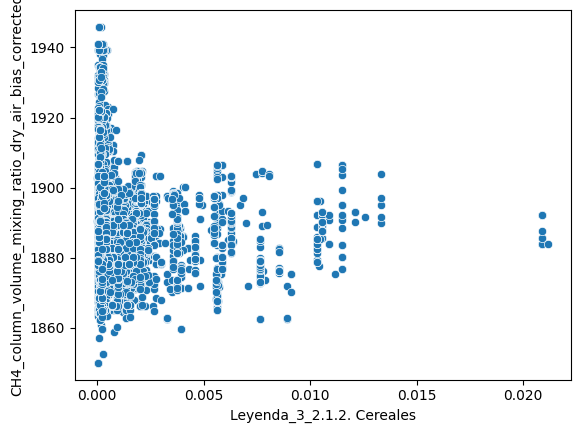

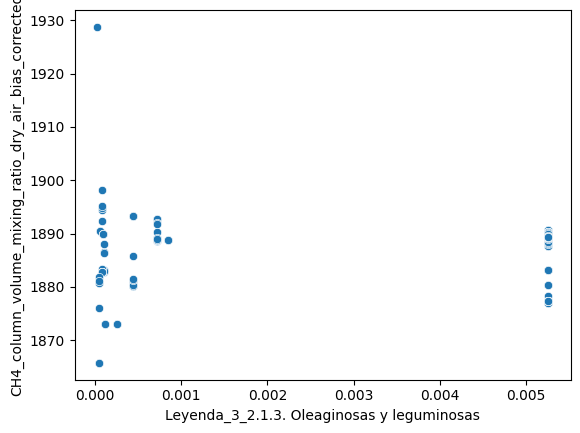

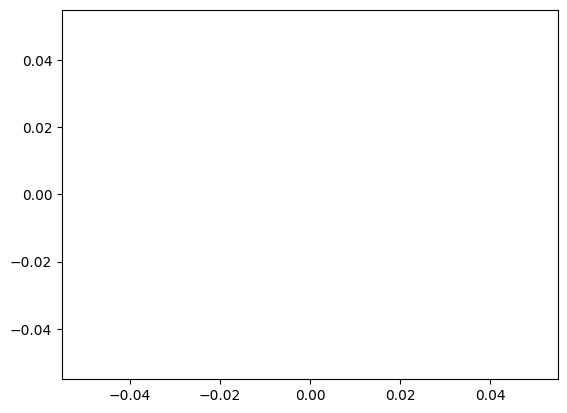

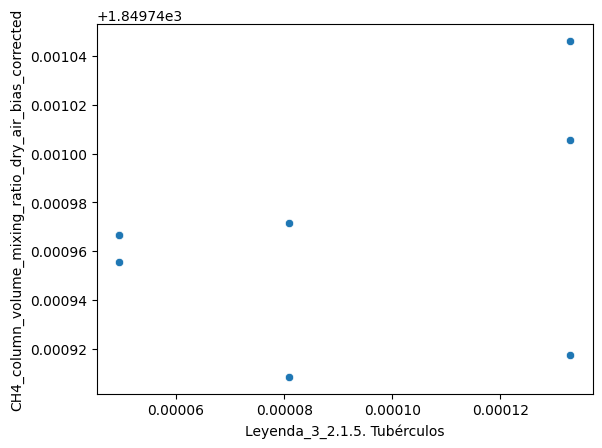

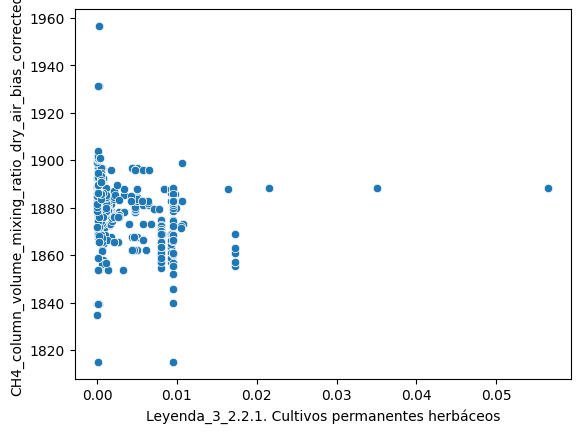

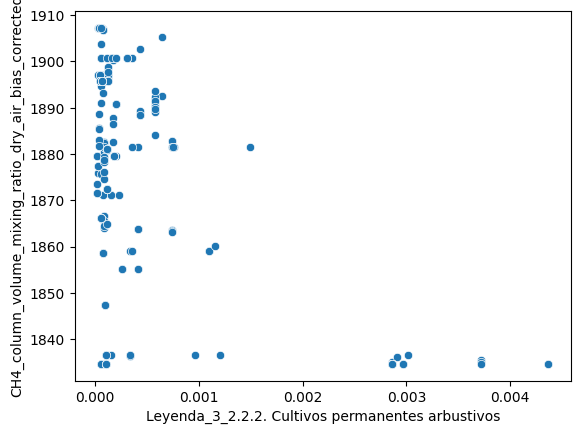

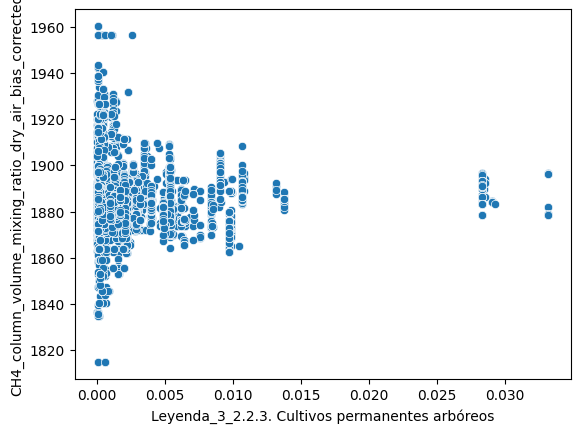

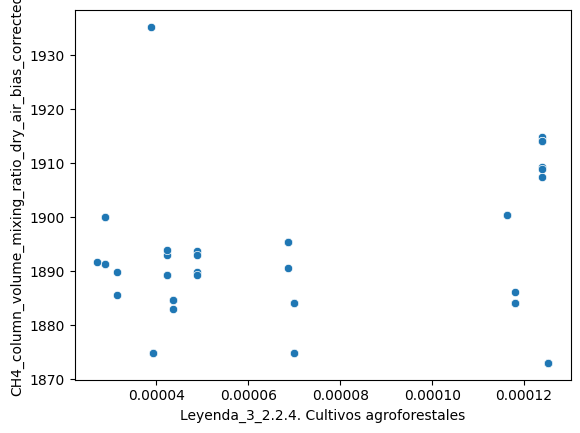

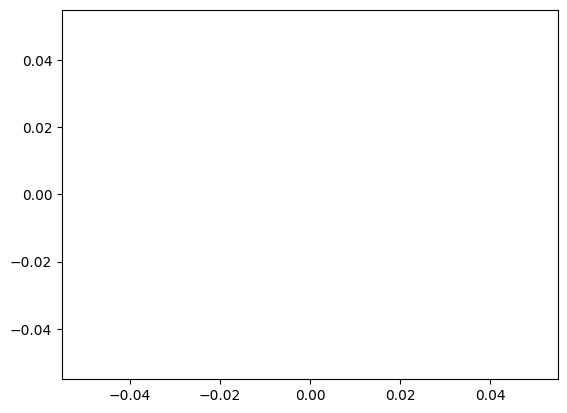

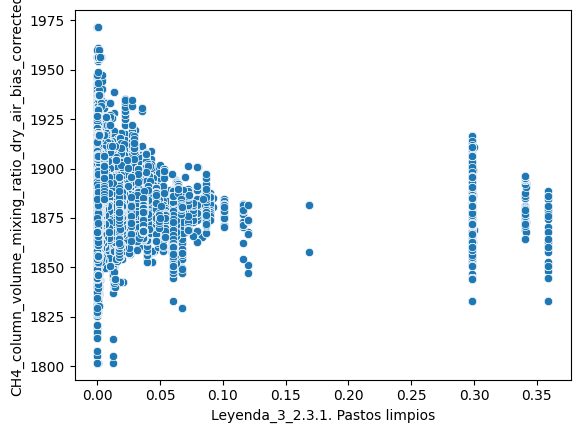

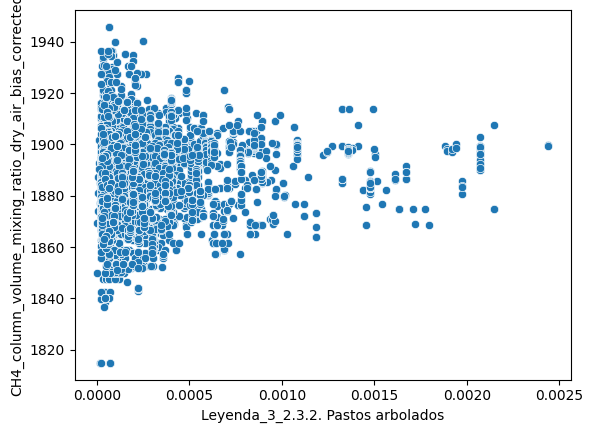

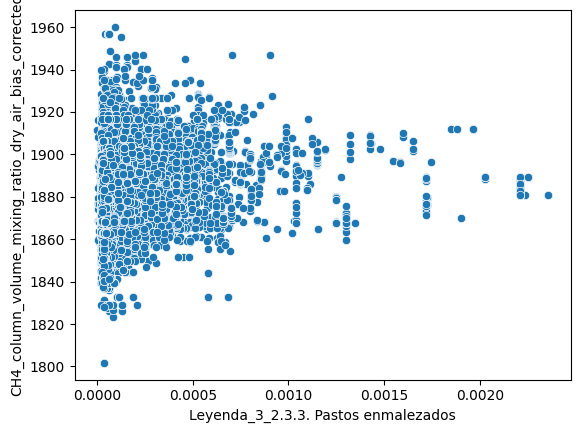

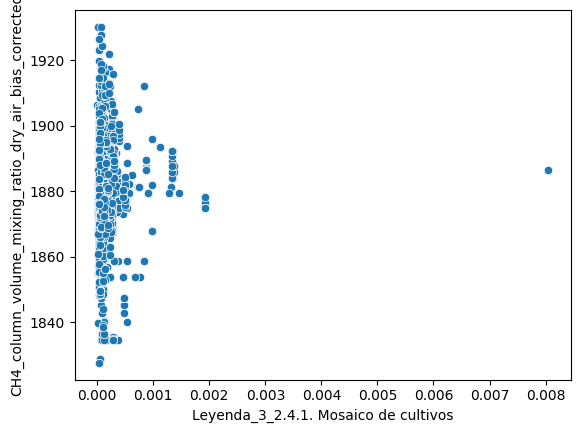

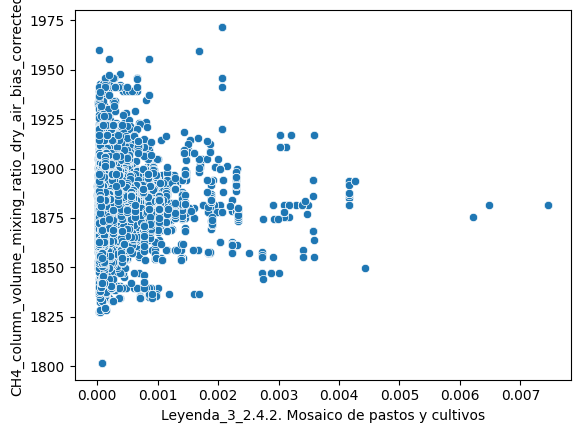

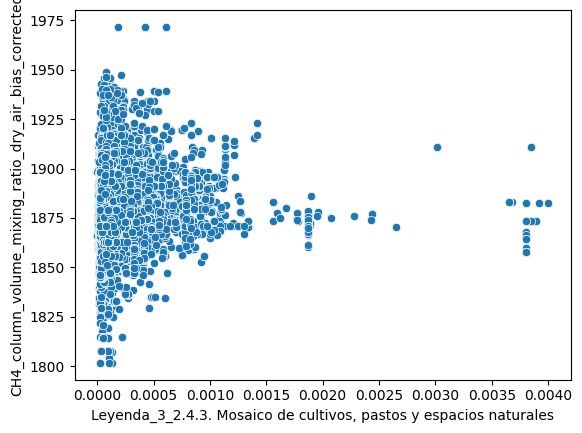

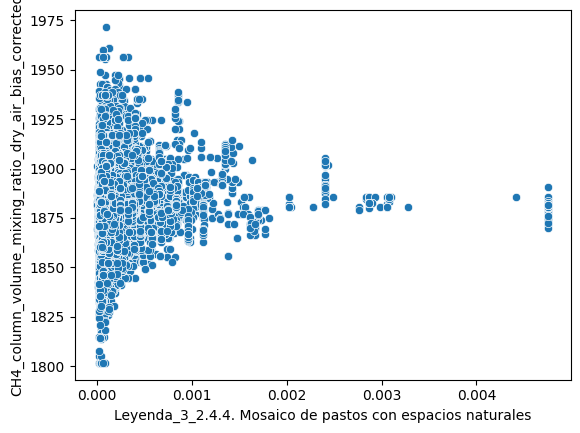

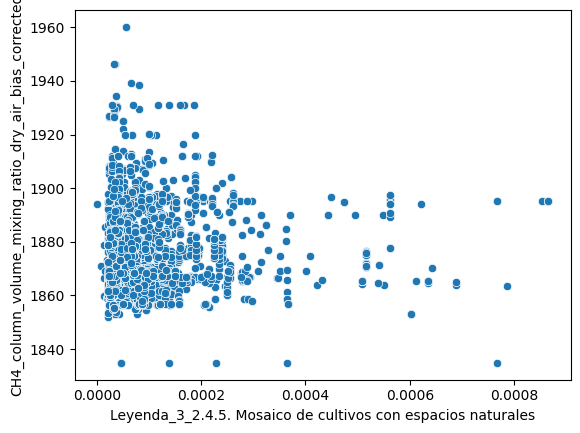

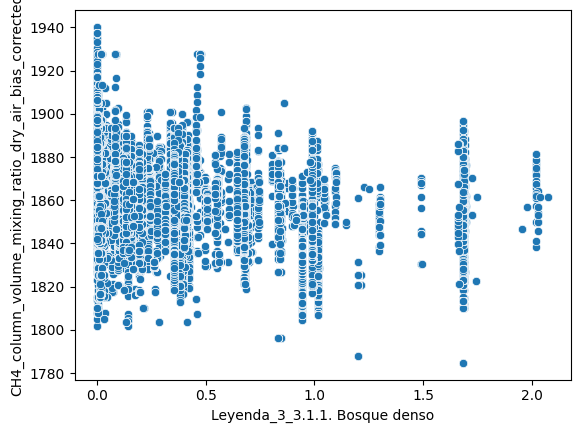

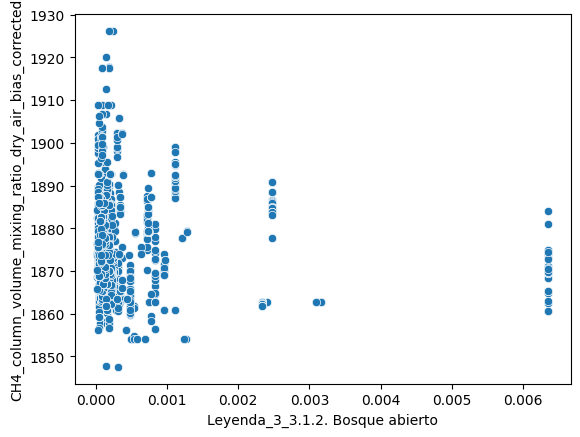

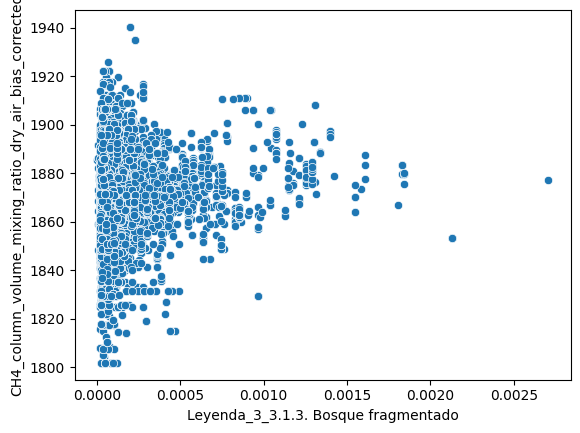

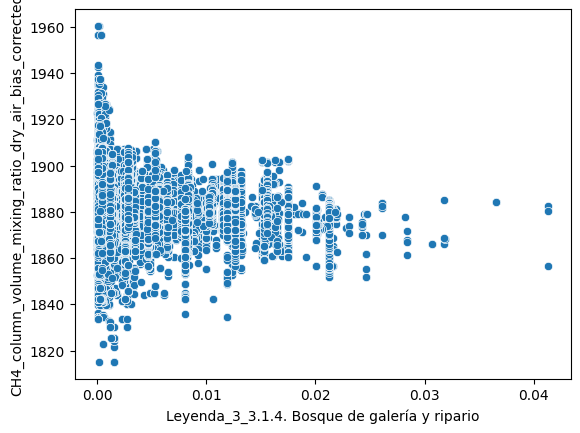

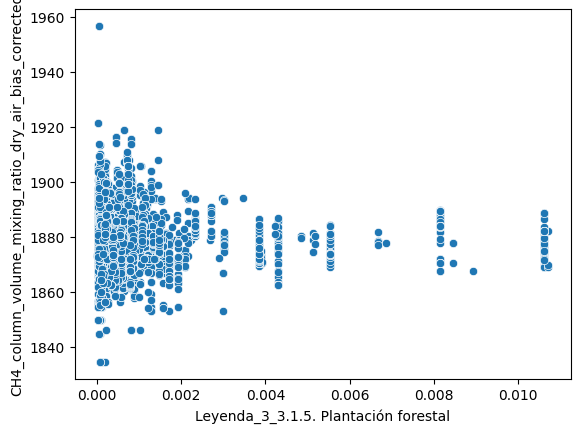

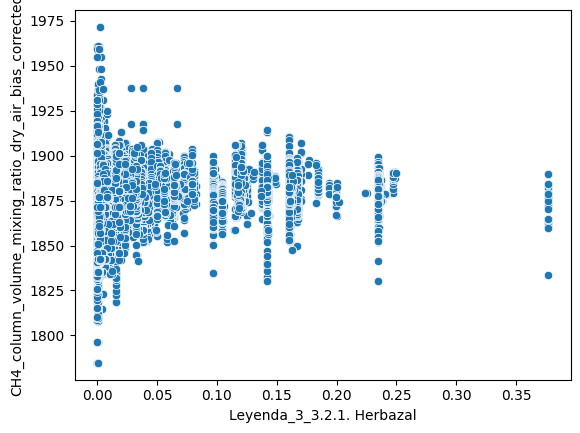

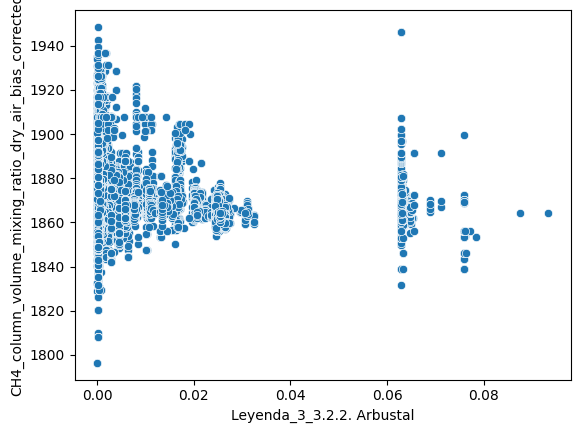

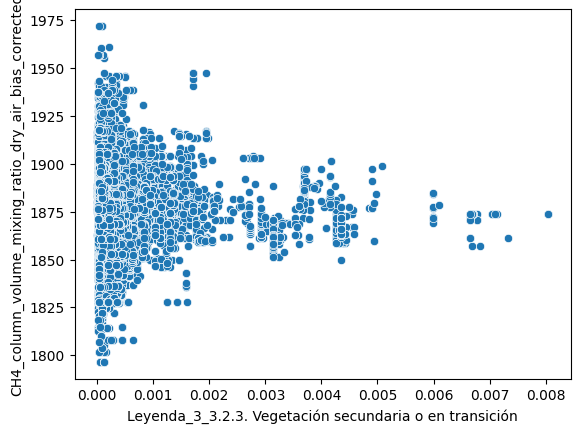

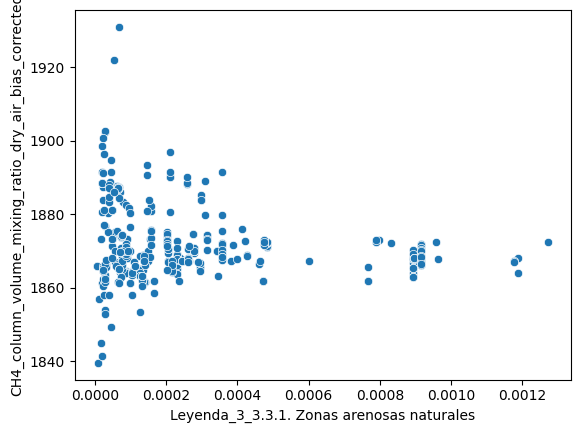

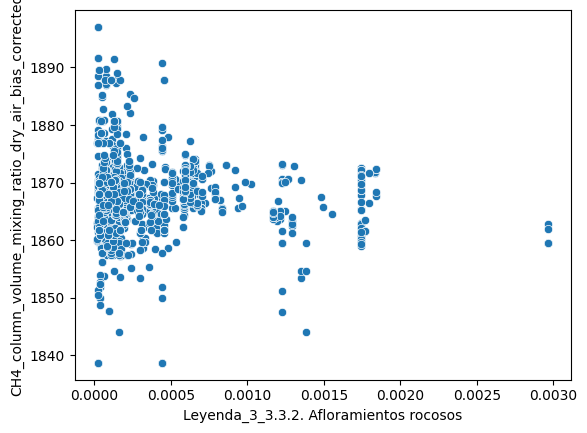

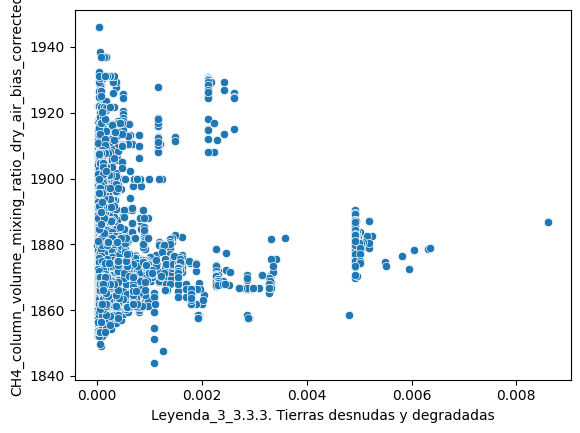

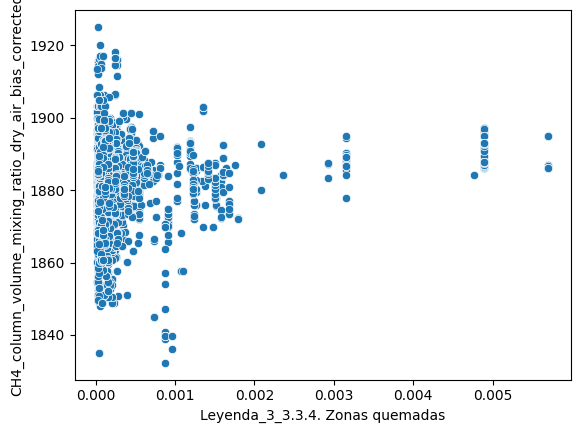

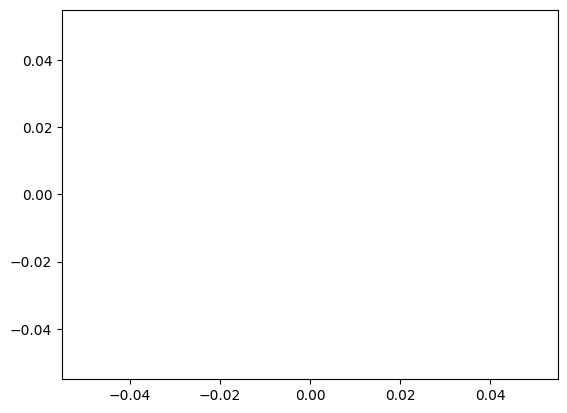

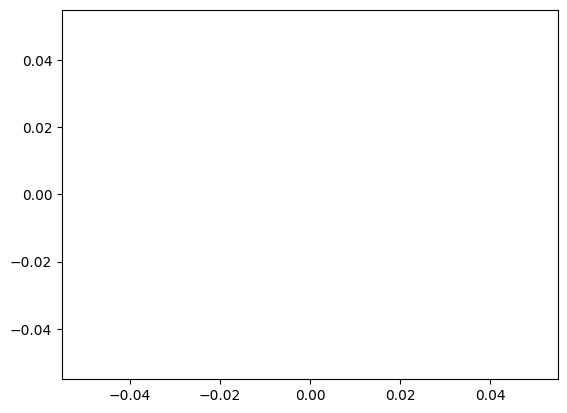

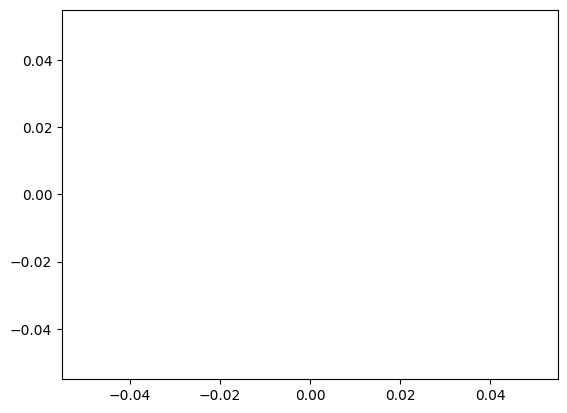

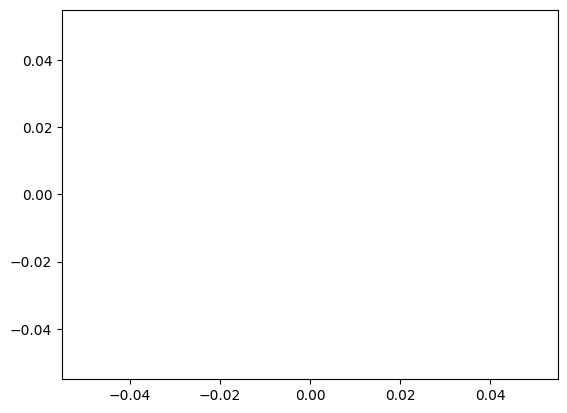

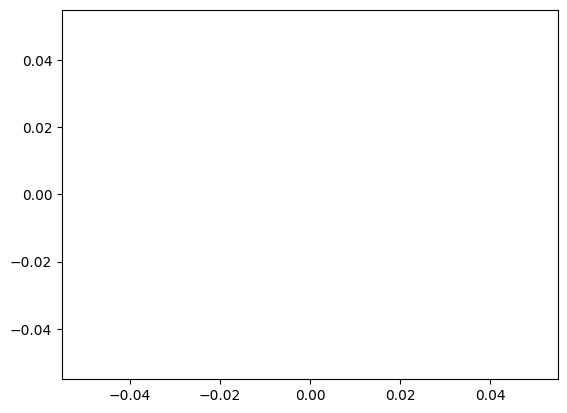

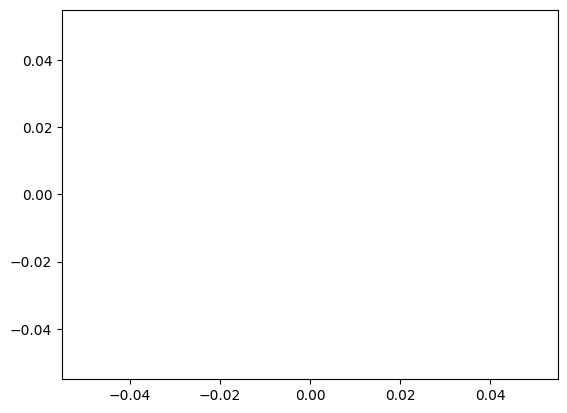

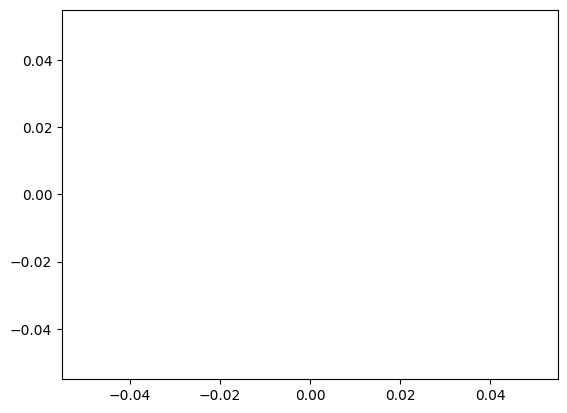

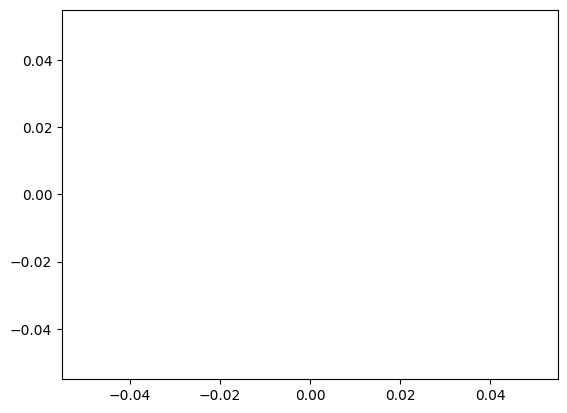

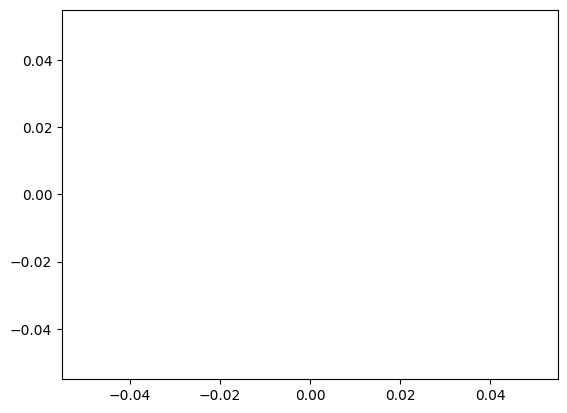

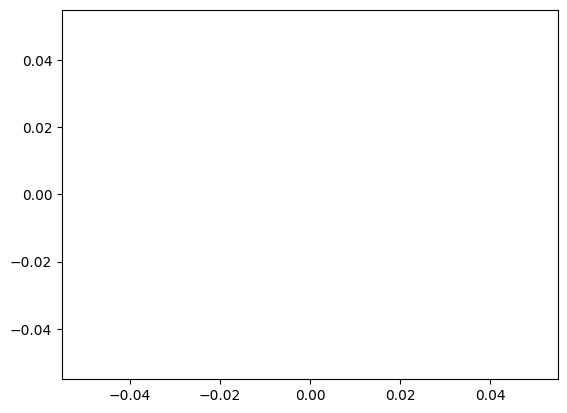

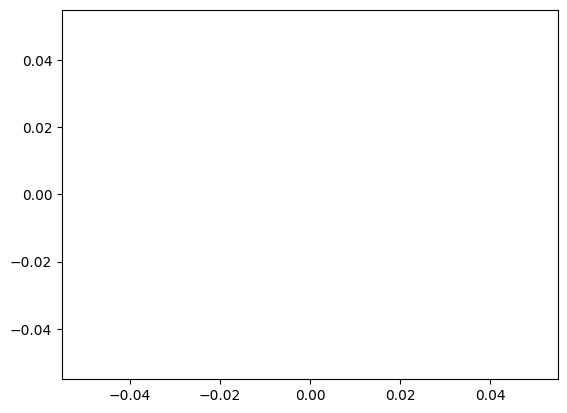

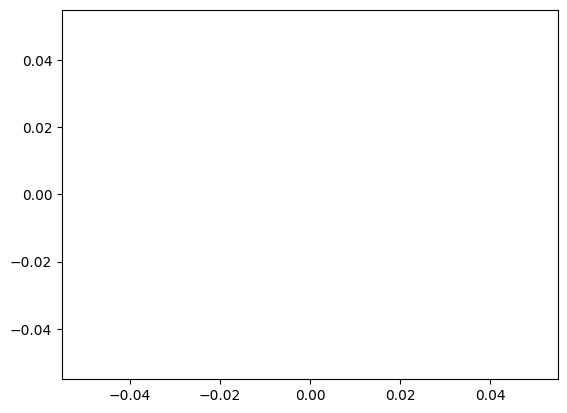

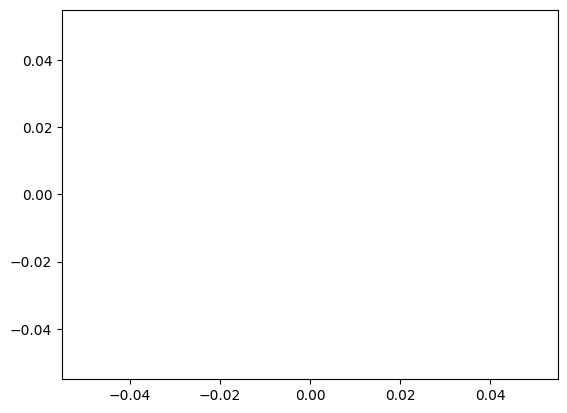

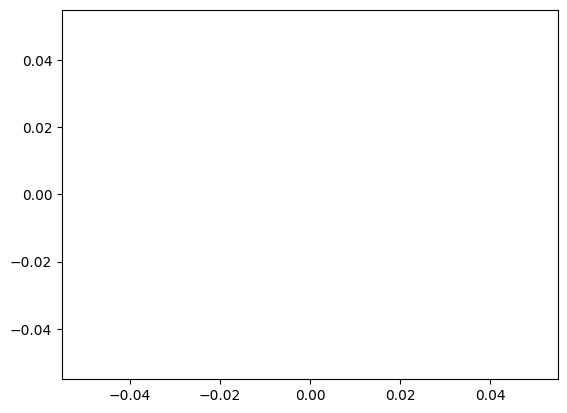

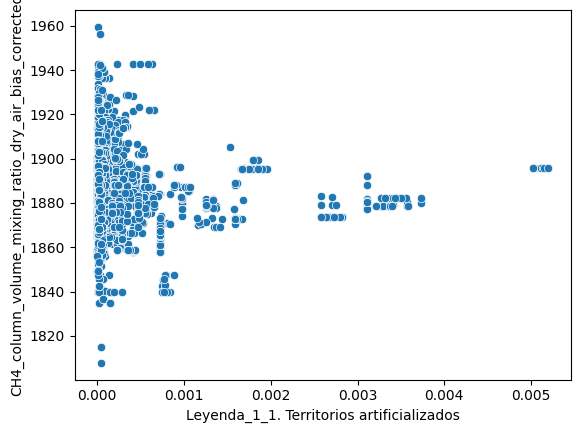

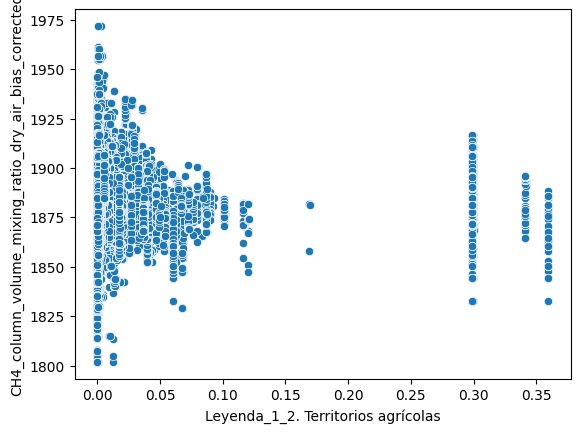

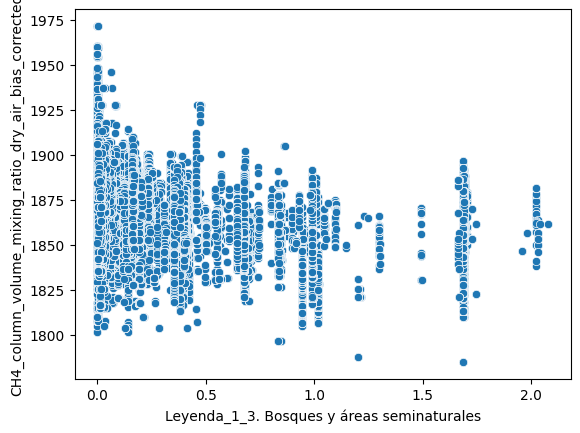

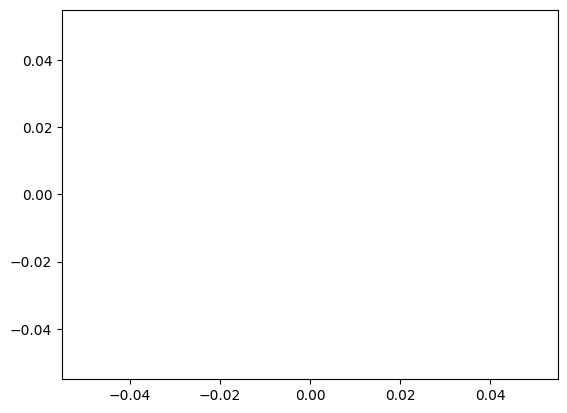

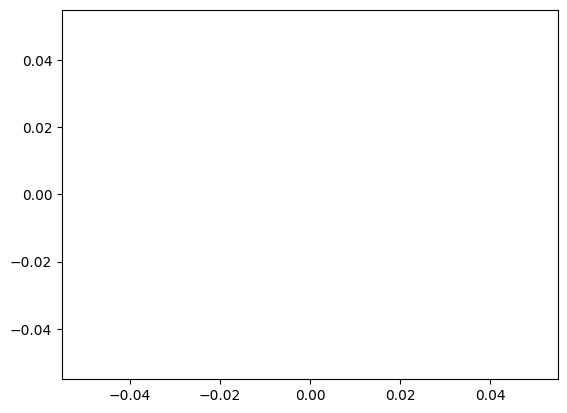

In [8]:
d={}
for i in l_in:
    #df_filtered = df_corr[df_corr[i] >1e-15]
    df_corr.loc[df_corr[i] ==0, i] = np.nan
    #transformed, lambda_ = stats.boxcox(df_corr[i])
    #cor=df_filtered['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'].corr(df_filtered[i])
    #d[i]=cor
    sns.scatterplot(x=i,y='CH4_column_volume_mixing_ratio_dry_air_bias_corrected',data=df_corr)
    plt.show()

In [9]:
corr_final=pg.pairwise_corr(df_corr,columns=[['CH4_column_volume_mixing_ratio_dry_air_bias_corrected'],l_in])
corr_final.sort_values(by=['p-unc'])[['X', 'Y', 'n', 'r', 'p-unc','BF10']].head(60)

,X,Y,n,r,p-unc,BF10
40,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_1_3. Bosques y áreas seminaturales,250665,-0.482897,0.000000e+00,inf
26,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.1.1. Bosque denso,127240,-0.331142,0.000000e+00,inf
29,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.1.4. Bosque de galería y ripario,70581,-0.120994,2.338046e-228,4.93e+223
31,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.2.1. Herbazal,81544,0.098832,4.441002e-176,2.763e+171
32,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.2.2. Arbustal,15332,-0.193559,2.567605e-129,1.261e+125
39,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_1_2. Territorios agrícolas,125168,0.059747,2.395572e-99,5.55e+94
24,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.4.4. Mosaico de pastos con espacio...,51739,0.072035,1.730270e-60,1.537e+56
20,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.3.3. Pastos enmalezados,26454,0.096888,3.367812e-56,1.143e+52
18,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.3.1. Pastos limpios,97377,0.042172,1.383997e-39,1.746e+35
3,CH4_column_volume_mixing_ratio_dry_air_bias_co...,"Leyenda_3_1.2.2. Red vial, ferroviaria y terre...",494,-0.506620,1.445651e-33,2.05e+30


In [10]:
df_sorted = corr_final.reindex(corr_final['r'].abs().sort_values(ascending=False).index)
df_sorted#[(df_sorted['p-unc']<0.01)*(df_sorted['n']>20)].head(60)

,X,Y,method,alternative,n,r,CI95%,p-unc,BF10,power
7,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_1.3.2. Zona de disposición de residuos,pearson,two-sided,21,0.660051,"[0.32, 0.85]",1.129980e-03,38.329,0.928940
4,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_1.2.3. Zonas portuarias,pearson,two-sided,5,0.625789,"[-0.57, 0.97]",2.588128e-01,0.922,0.216961
15,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.2.2. Cultivos permanentes arbustivos,pearson,two-sided,233,-0.612635,"[-0.69, -0.53]",2.126635e-25,2.063e+22,1.000000
3,CH4_column_volume_mixing_ratio_dry_air_bias_co...,"Leyenda_3_1.2.2. Red vial, ferroviaria y terre...",pearson,two-sided,494,-0.506620,"[-0.57, -0.44]",1.445651e-33,2.05e+30,1.000000
40,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_1_3. Bosques y áreas seminaturales,pearson,two-sided,250665,-0.482897,"[-0.49, -0.48]",0.000000e+00,inf,1.000000
26,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.1.1. Bosque denso,pearson,two-sided,127240,-0.331142,"[-0.34, -0.33]",0.000000e+00,inf,1.000000
13,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.1.5. Tubérculos,pearson,two-sided,8,0.322135,"[-0.49, 0.84]",4.364806e-01,0.561,0.123667
1,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_1.1.2. Tejido urbano discontinuo,pearson,two-sided,1764,-0.244193,"[-0.29, -0.2]",2.309043e-25,9.376e+21,1.000000
32,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.2.2. Arbustal,pearson,two-sided,15332,-0.193559,"[-0.21, -0.18]",2.567605e-129,1.261e+125,1.000000
27,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.1.2. Bosque abierto,pearson,two-sided,1199,-0.160564,"[-0.22, -0.1]",2.267061e-08,2.169e+05,0.999866


In [11]:
#dfg.groupby('nivel_3').nunique()['leyenda']

In [12]:
df_corr.loc[df_corr['Leyenda_1_2. Territorios agrícolas'] !=0 ]

,longitude,latitude,time,CH4_column_volume_mixing_ratio_dry_air_bias_corrected,coordinate_x,coordinate_y,coordinates,geometry,Leyenda_3_1.1.1. Tejido urbano continuo,Leyenda_3_1.1.2. Tejido urbano discontinuo,...,Leyenda_3_5.1.3. Canales,Leyenda_3_5.1.4. Cuerpos de agua artificiales,Leyenda_3_5.2.1. Lagunas costeras,Leyenda_3_5.2.2. Mares y océanos,Leyenda_3_5.2.3. Estanques para acuicultura marina,Leyenda_1_1. Territorios artificializados,Leyenda_1_2. Territorios agrícolas,Leyenda_1_3. Bosques y áreas seminaturales,Leyenda_1_4. Áreas húmedas,Leyenda_1_5. Superficies de agua
0,-77.305,7.745,1.606068e+12,1866.559650,[-77.305],[7.745],"[-77.305, 7.745]","POLYGON ((-77.31 7.74, -77.31 7.75, -77.300000...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000038,0.286843,NaN,NaN
1,-77.305,7.755,1.606068e+12,1866.559615,[-77.305],[7.755],"[-77.305, 7.755]","POLYGON ((-77.31 7.75, -77.31 7.76, -77.300000...",NaN,0.000006,...,NaN,NaN,NaN,NaN,NaN,0.000006,0.000161,0.286593,NaN,NaN
2,-77.295,7.705,1.606068e+12,1866.559567,[-77.295],[7.705],"[-77.295, 7.705]","POLYGON ((-77.3 7.7, -77.3 7.71, -77.29 7.71, ...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000725,0.000777,NaN,NaN
3,-77.295,7.715,1.606068e+12,1866.559602,[-77.295],[7.715],"[-77.295, 7.715]","POLYGON ((-77.3 7.71, -77.3 7.72, -77.29 7.72,...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000482,0.000854,NaN,NaN
4,-77.295,7.725,1.606068e+12,1866.559608,[-77.295],[7.725],"[-77.295, 7.725]","POLYGON ((-77.3 7.72, -77.3 7.7299999999999995...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0.000328,0.000878,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307148,-67.325,3.435,1.577987e+12,1835.456487,[-67.325],[3.435],"[-67.325, 3.435]","POLYGON ((-67.33 3.43, -67.33 3.44, -67.320000...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307149,-67.325,3.445,1.577987e+12,1835.456421,[-67.325],[3.4450000000000003],"[-67.325, 3.4450000000000003]","POLYGON ((-67.33 3.4400000000000004, -67.33 3....",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307150,-67.325,3.455,1.577987e+12,1835.456421,[-67.325],[3.455],"[-67.325, 3.455]","POLYGON ((-67.33 3.45, -67.33 3.46, -67.320000...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
307153,-67.315,3.435,1.577987e+12,1835.456439,[-67.315],[3.435],"[-67.315, 3.435]","POLYGON ((-67.32 3.43, -67.32 3.44, -67.31 3.4...",NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
df_sorted['abs']=df_sorted['r'].abs()
df_sorted.to_csv(r'correlaciones_fil.csv')

In [15]:
import statsmodels
#df_cor_filtered['p-val'].to_numpy()
p_corrected=statsmodels.stats.multitest.multipletests(df_sorted['p-unc'],method='fdr_bh')
#p_corrected=statsmodels.stats.multitest.fdrcorrection(p_vals)
df_sorted[p_corrected[0]*(df_sorted['n']>20)]

,X,Y,method,alternative,n,r,CI95%,p-unc,BF10,power,abs
7,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_1.3.2. Zona de disposición de residuos,pearson,two-sided,21,0.660051,"[0.32, 0.85]",1.129980e-03,38.329,0.928940,0.660051
15,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.2.2. Cultivos permanentes arbustivos,pearson,two-sided,233,-0.612635,"[-0.69, -0.53]",2.126635e-25,2.063e+22,1.000000,0.612635
3,CH4_column_volume_mixing_ratio_dry_air_bias_co...,"Leyenda_3_1.2.2. Red vial, ferroviaria y terre...",pearson,two-sided,494,-0.506620,"[-0.57, -0.44]",1.445651e-33,2.05e+30,1.000000,0.506620
40,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_1_3. Bosques y áreas seminaturales,pearson,two-sided,250665,-0.482897,"[-0.49, -0.48]",0.000000e+00,inf,1.000000,0.482897
26,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.1.1. Bosque denso,pearson,two-sided,127240,-0.331142,"[-0.34, -0.33]",0.000000e+00,inf,1.000000,0.331142
1,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_1.1.2. Tejido urbano discontinuo,pearson,two-sided,1764,-0.244193,"[-0.29, -0.2]",2.309043e-25,9.376e+21,1.000000,0.244193
32,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.2.2. Arbustal,pearson,two-sided,15332,-0.193559,"[-0.21, -0.18]",2.567605e-129,1.261e+125,1.000000,0.193559
27,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.1.2. Bosque abierto,pearson,two-sided,1199,-0.160564,"[-0.22, -0.1]",2.267061e-08,2.169e+05,0.999866,0.160564
34,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.3.1. Zonas arenosas naturales,pearson,two-sided,385,-0.158314,"[-0.25, -0.06]",1.833778e-03,8.038,0.877822,0.158314
37,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.3.4. Zonas quemadas,pearson,two-sided,3936,0.148209,"[0.12, 0.18]",9.019255e-21,1.839e+17,1.000000,0.148209


In [16]:
df_cor_filtered=df_sorted.copy()
df_cor_filtered['reject_bh']=p_corrected[0]
df_cor_filtered['reject_cb']=df_cor_filtered['p-unc']<p_corrected[3]
df_cor_filtered['p_corregido']=p_corrected[1]
df_cor_filtered

,X,Y,method,alternative,n,r,CI95%,p-unc,BF10,power,abs,reject_bh,reject_cb,p_corregido
7,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_1.3.2. Zona de disposición de residuos,pearson,two-sided,21,0.660051,"[0.32, 0.85]",1.129980e-03,38.329,0.928940,0.660051,True,True,2.316459e-03
4,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_1.2.3. Zonas portuarias,pearson,two-sided,5,0.625789,"[-0.57, 0.97]",2.588128e-01,0.922,0.216961,0.625789,False,False,3.031808e-01
15,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.2.2. Cultivos permanentes arbustivos,pearson,two-sided,233,-0.612635,"[-0.69, -0.53]",2.126635e-25,2.063e+22,1.000000,0.612635,True,True,7.266003e-25
3,CH4_column_volume_mixing_ratio_dry_air_bias_co...,"Leyenda_3_1.2.2. Red vial, ferroviaria y terre...",pearson,two-sided,494,-0.506620,"[-0.57, -0.44]",1.445651e-33,2.05e+30,1.000000,0.506620,True,True,5.927171e-33
40,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_1_3. Bosques y áreas seminaturales,pearson,two-sided,250665,-0.482897,"[-0.49, -0.48]",0.000000e+00,inf,1.000000,0.482897,True,True,0.000000e+00
26,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.1.1. Bosque denso,pearson,two-sided,127240,-0.331142,"[-0.34, -0.33]",0.000000e+00,inf,1.000000,0.331142,True,True,0.000000e+00
13,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_2.1.5. Tubérculos,pearson,two-sided,8,0.322135,"[-0.49, 0.84]",4.364806e-01,0.561,0.123667,0.322135,False,False,4.709396e-01
1,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_1.1.2. Tejido urbano discontinuo,pearson,two-sided,1764,-0.244193,"[-0.29, -0.2]",2.309043e-25,9.376e+21,1.000000,0.244193,True,True,7.282366e-25
32,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.2.2. Arbustal,pearson,two-sided,15332,-0.193559,"[-0.21, -0.18]",2.567605e-129,1.261e+125,1.000000,0.193559,True,True,2.105436e-128
27,CH4_column_volume_mixing_ratio_dry_air_bias_co...,Leyenda_3_3.1.2. Bosque abierto,pearson,two-sided,1199,-0.160564,"[-0.22, -0.1]",2.267061e-08,2.169e+05,0.999866,0.160564,True,True,5.809345e-08
